# Multi-Run Drift Detection Timing Analysis
This notebook aggregates and analyzes drift detection timing data from multiple experimental runs to provide robust statistical insights into technique performance, variability, and consistency.

In [32]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from pathlib import Path
from scipy import stats
from itertools import combinations
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

In [33]:
def load_all_timing_data():
    """
    Load and aggregate timing data from all experimental runs.
    
    Returns:
        pd.DataFrame: Combined timing data with run_id column
    """
    base_path = Path('/Users/lucashelfstein/Documents/Masters/EmpiricalAnalysisOfDataDrift/comparison_results/statistical_relevance_published_results/runs')
    all_timing_data = []
    successful_runs = []
    failed_runs = []
    
    # Load data from each run
    for run_num in range(1, 32):  # runs 001 to 031
        run_id = f"run_{run_num:03d}"
        timing_file = base_path / run_id / 'timing' / 'timing_summary.csv'
        
        try:
            run_data = pd.read_csv(timing_file)
            run_data['run_id'] = run_id
            all_timing_data.append(run_data)
            successful_runs.append(run_id)
        except Exception as e:
            failed_runs.append(run_id)
    
    # Combine all data
    if all_timing_data:
        combined_df = pd.concat(all_timing_data, ignore_index=True)
        print(f"✅ Successfully loaded data from {len(successful_runs)} runs")
        print(f"📊 Total records: {len(combined_df):,}")
        
        if failed_runs:
            print(f"⚠️ Failed to load data from {len(failed_runs)} runs: {failed_runs}")
        
        return combined_df
    else:
        raise ValueError("No timing data could be loaded from any run!")

In [ ]:
# Check unique technique names before mapping
print("Unique technique names before mapping:")
print(sorted(timing_data['technique'].unique()))

# Apply technique name mappings
technique_mappings = {
    'HDDDM': 'HD',
    'JSDDM': 'JS',
    'KSDDM_90': 'KS90',
    'KSDDM_95': 'KS95'
}

timing_data['technique'] = timing_data['technique'].replace(technique_mappings)

print("\nUnique technique names after mapping:")
print(sorted(timing_data['technique'].unique()))

print("\nMapping summary:")
for old_name, new_name in technique_mappings.items():
    count = len(timing_data[timing_data['technique'] == new_name])
    print(f"{old_name} -> {new_name}: {count} records")

In [46]:
# Main Analysis
print("🚀 Starting Multi-Run Drift Detection Timing Analysis")

# Load and prepare data
timing_data = load_all_timing_data()
timing_data

🚀 Starting Multi-Run Drift Detection Timing Analysis
✅ Successfully loaded data from 31 runs
📊 Total records: 4,464


,dataset,batch_size,technique,phase,duration_seconds,type,run_id
0,synthetic_dataset_with_parallel_drifts_abrupt,1000,HDDDM,drift_detection,0.192697,technique_timing,run_001
1,synthetic_dataset_with_parallel_drifts_abrupt,1000,KSDDM_95,drift_detection,0.904395,technique_timing,run_001
2,synthetic_dataset_with_parallel_drifts_abrupt,1000,KSDDM_90,drift_detection,0.784658,technique_timing,run_001
3,synthetic_dataset_with_parallel_drifts_abrupt,1000,JSDDM,drift_detection,0.151973,technique_timing,run_001
4,synthetic_dataset_with_parallel_drifts_abrupt,1500,HDDDM,drift_detection,0.147435,technique_timing,run_001
...,...,...,...,...,...,...,...
4459,synthetic_dataset_no_drifts,2500,ALL,total,2.997703,batch_total,run_031
4460,ALL,ALL,HDDDM,drift_detection,0.157271,technique_avg,run_031
4461,ALL,ALL,KSDDM_95,drift_detection,0.794985,technique_avg,run_031
4462,ALL,ALL,KSDDM_90,drift_detection,0.691228,technique_avg,run_031


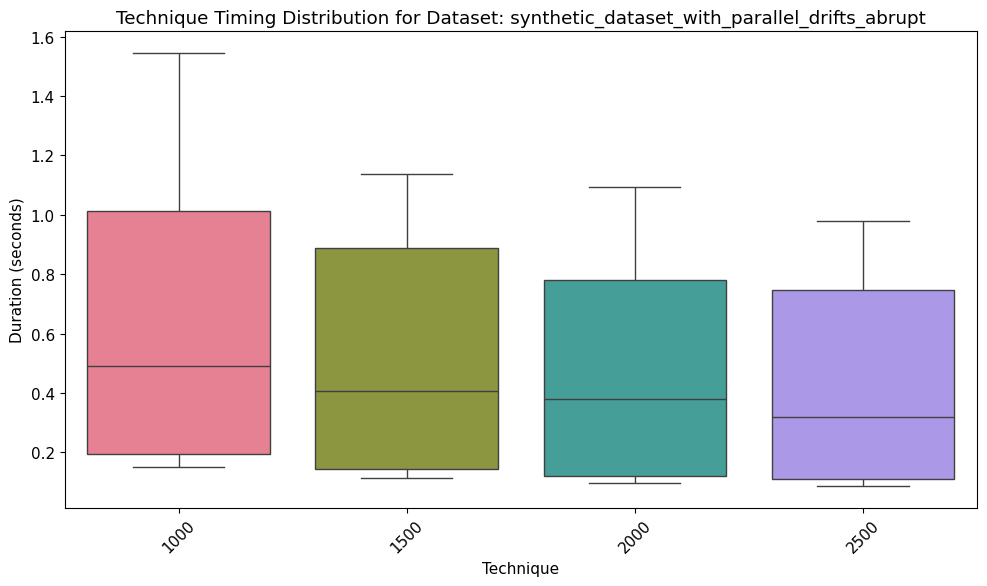

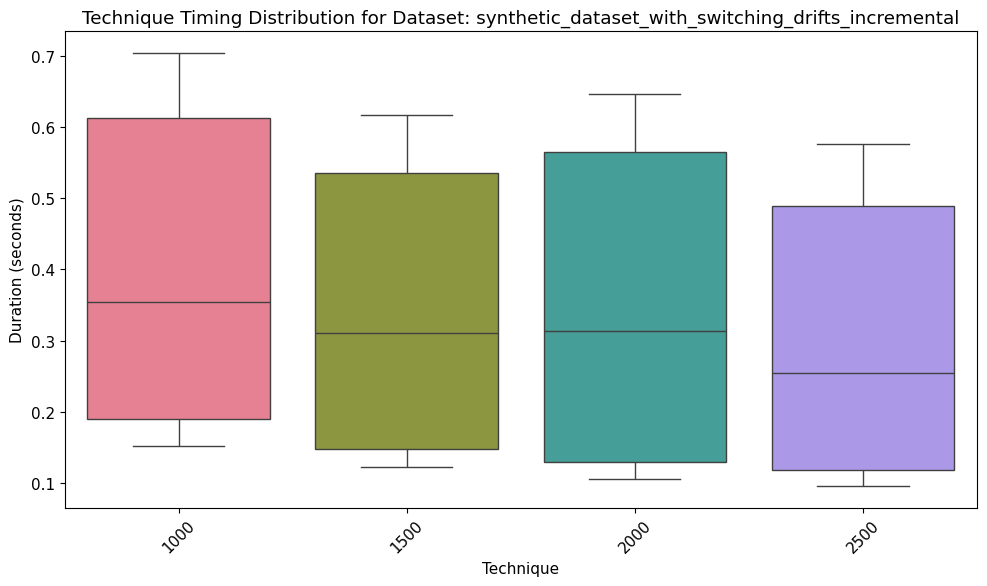

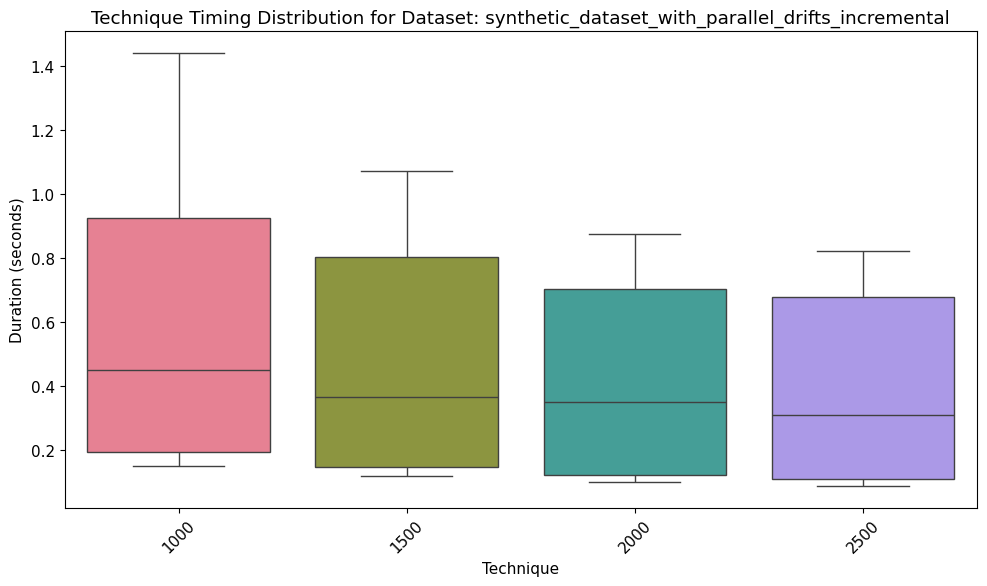

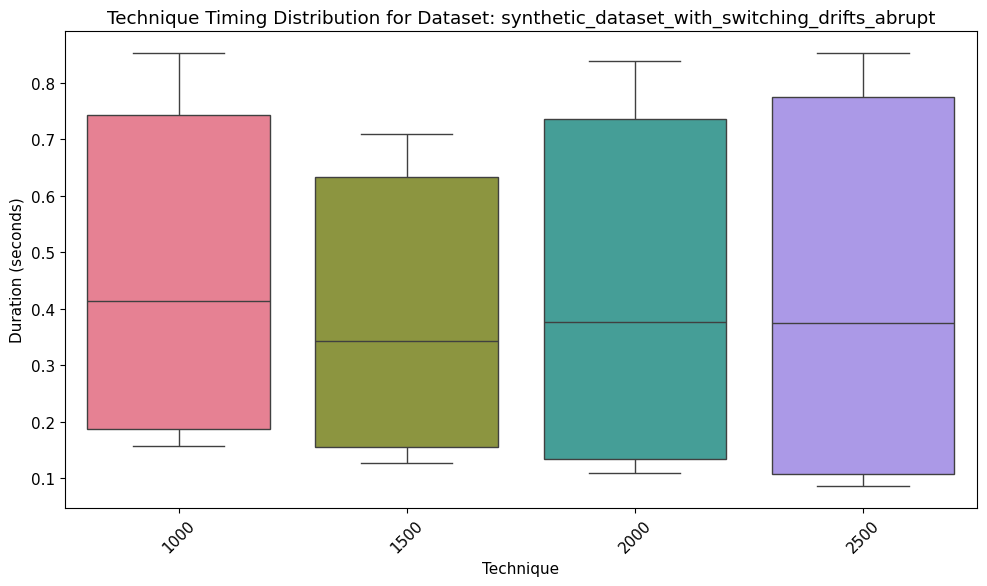

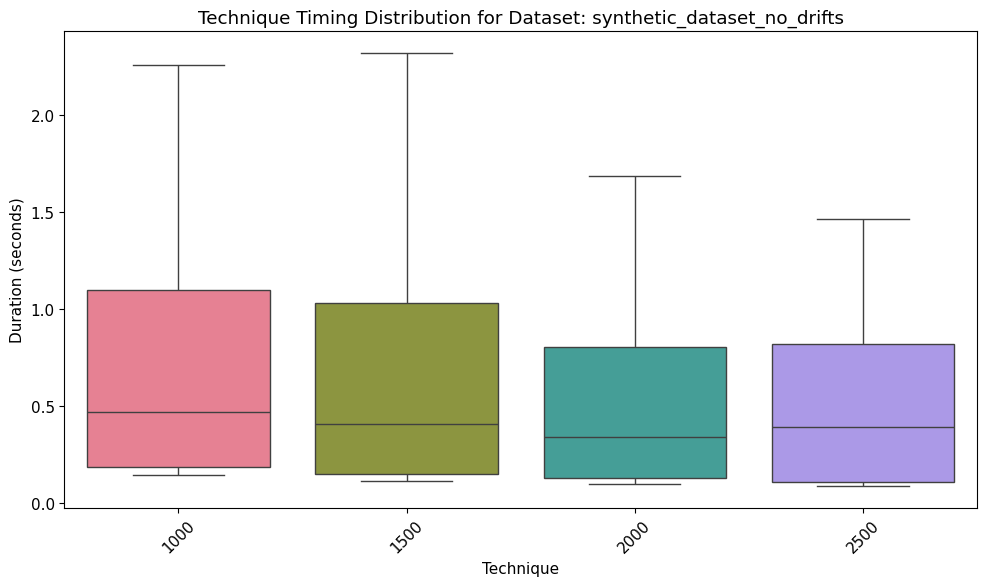

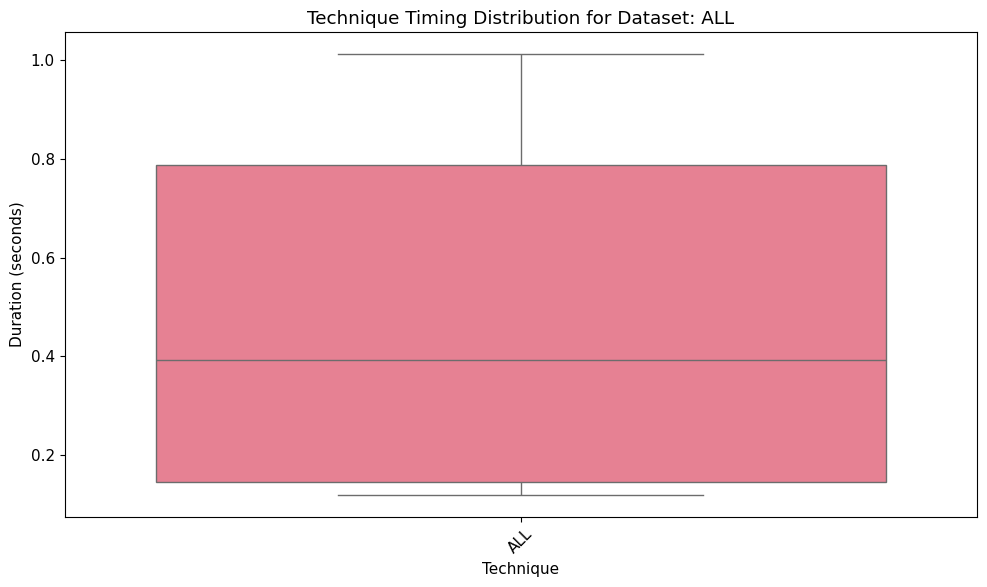

In [35]:
for dataset in timing_data['dataset'].unique():
    subset = timing_data[(timing_data['dataset'] == dataset) & (timing_data['technique'] != 'ALL')]
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=subset, x='batch_size', y='duration_seconds', palette='husl', showfliers=False)
    plt.title(f'Technique Timing Distribution for Dataset: {dataset}')
    plt.xlabel('Technique')
    plt.ylabel('Duration (seconds)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [36]:
# Filter for drift detection phase
drift_detection_data = timing_data[timing_data['phase'] == 'drift_detection']

# Display basic information
print(f"Shape: {drift_detection_data.shape}")
print(f"Columns: {list(drift_detection_data.columns)}")
print(f"Unique techniques: {drift_detection_data['technique'].nunique()}")

# Compute Average Drift Detection Time per Technique
average_drift_detection_time = drift_detection_data.groupby('technique')['duration_seconds'].mean().sort_values()
print(average_drift_detection_time)

Shape: (2604, 7)
Columns: ['dataset', 'batch_size', 'technique', 'phase', 'duration_seconds', 'type', 'run_id']
Unique techniques: 4
technique
JSDDM       0.124565
HDDDM       0.156739
KSDDM_90    0.739823
KSDDM_95    0.861552
Name: duration_seconds, dtype: float64


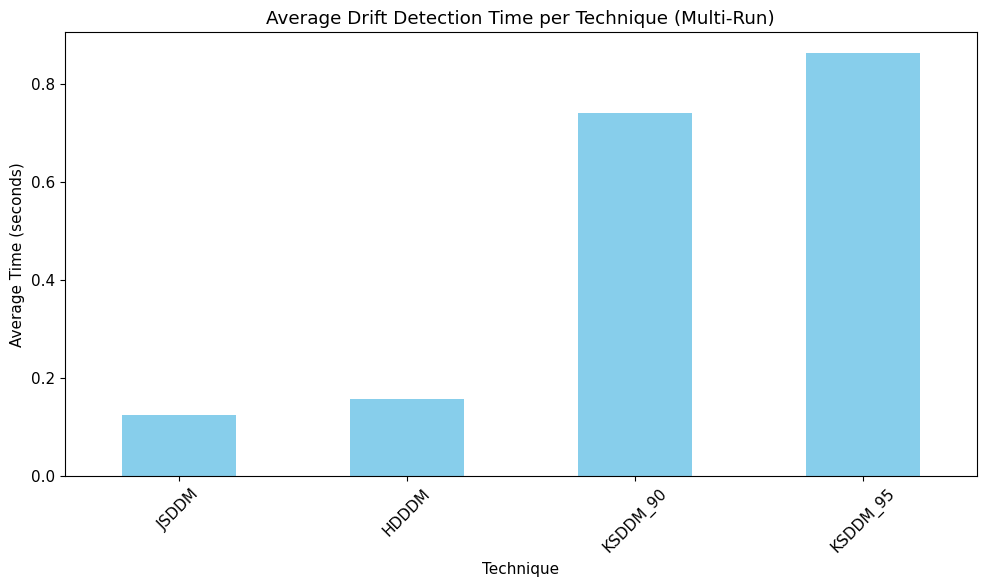

In [37]:
# Visualize Average Drift Detection Time per Technique
plt.figure(figsize=(10, 6))
average_drift_detection_time.plot(kind='bar', color='skyblue')
plt.title('Average Drift Detection Time per Technique (Multi-Run)')
plt.xlabel('Technique')
plt.ylabel('Average Time (seconds)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('./images/average_drift_detection_time_per_technique.png')
plt.show()

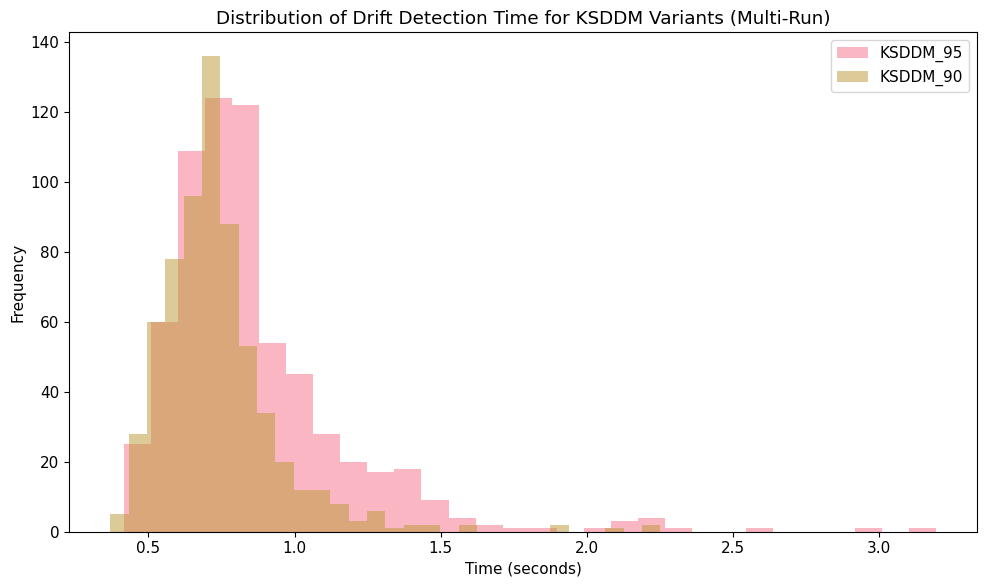

In [38]:
# Investigate KSDDM Timing
ksddm_data = drift_detection_data[drift_detection_data['technique'].str.contains('KSDDM')]

# Plot distribution of KSDDM timing
plt.figure(figsize=(10, 6))
for technique in ksddm_data['technique'].unique():
    subset = ksddm_data[ksddm_data['technique'] == technique]
    plt.hist(subset['duration_seconds'], bins=30, alpha=0.5, label=technique)

plt.title('Distribution of Drift Detection Time for KSDDM Variants (Multi-Run)')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('./images/ksddm_timing_distribution.png')
plt.show()

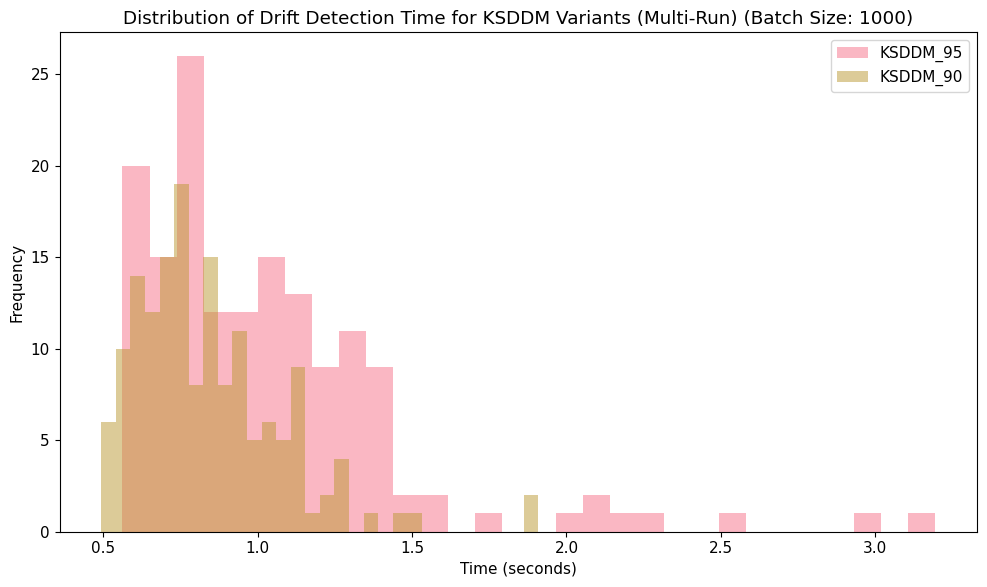

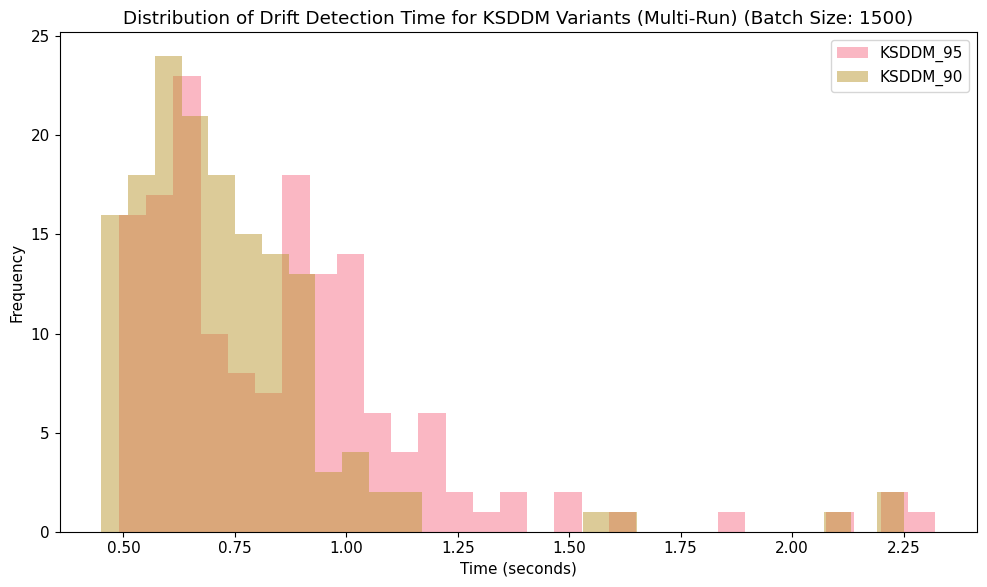

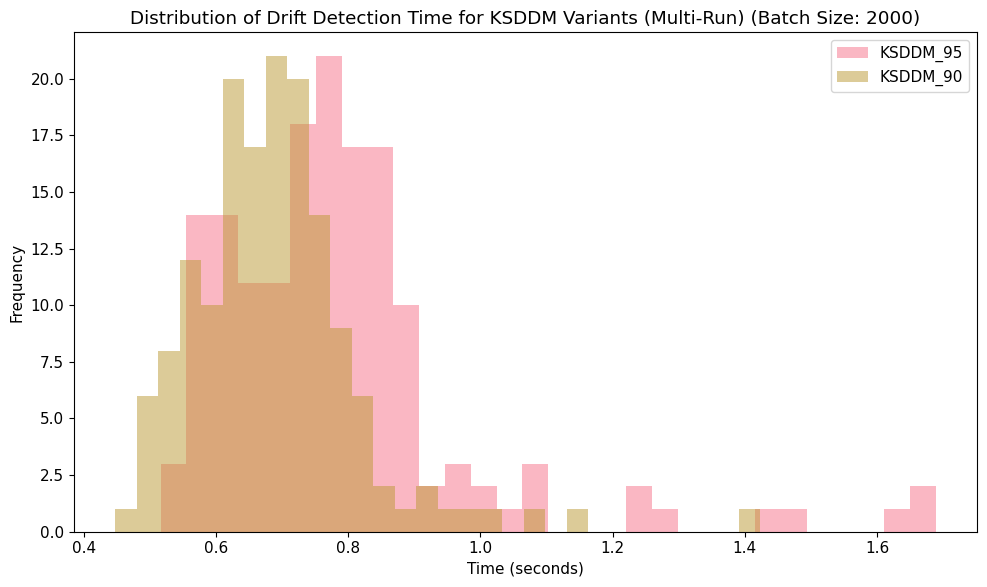

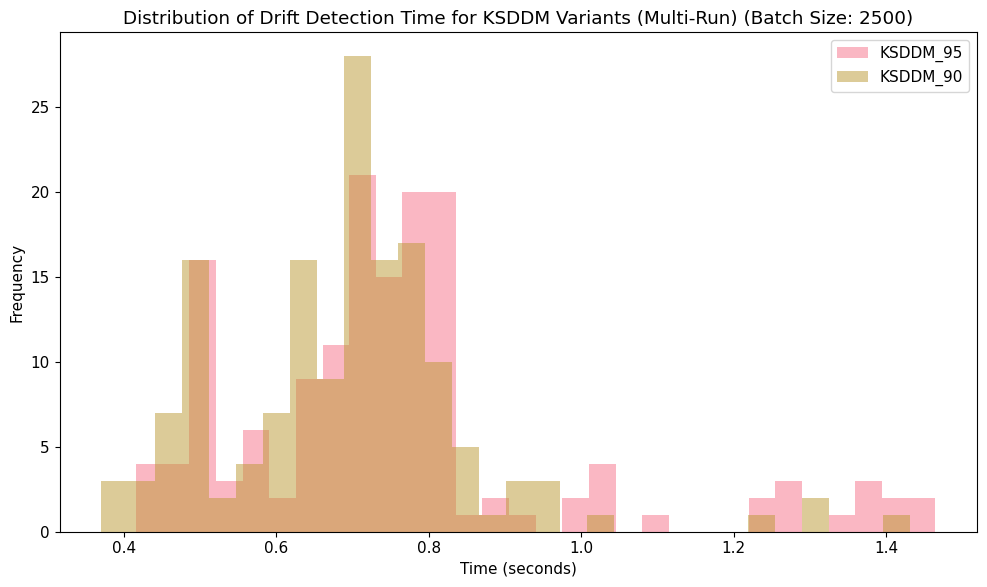

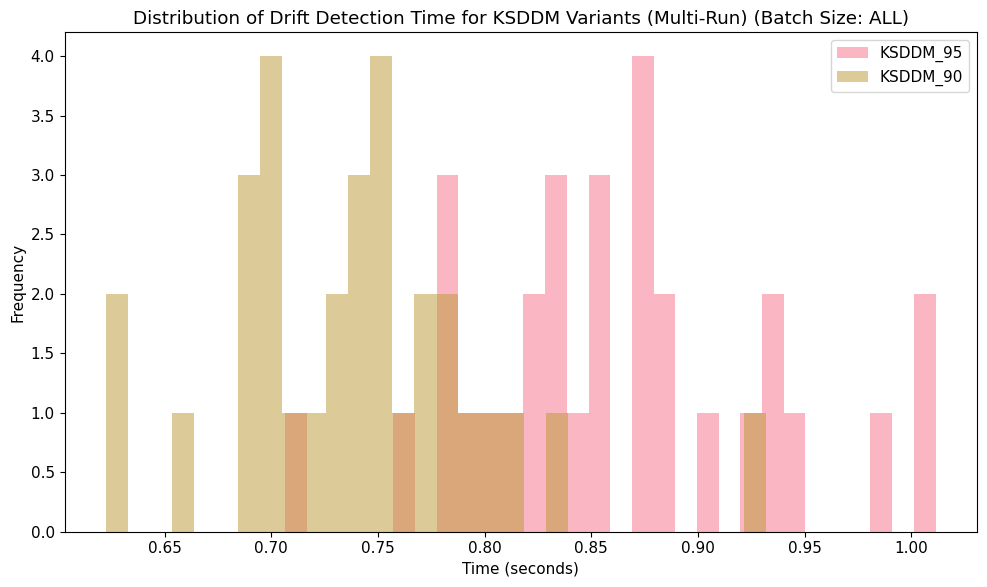

In [39]:
# Visualize Average Drift Detection Time per Technique for Each Batch Size
unique_batch_sizes = drift_detection_data['batch_size'].unique()
for batch_size in unique_batch_sizes:
    subset = drift_detection_data[drift_detection_data['batch_size'] == batch_size]
    
    ksddm_data = subset[subset['technique'].str.contains('KSDDM')]

    # Plot distribution of KSDDM timing
    plt.figure(figsize=(10, 6))
    for technique in ksddm_data['technique'].unique():
        subset = ksddm_data[ksddm_data['technique'] == technique]
        plt.hist(subset['duration_seconds'], bins=30, alpha=0.5, label=technique)

    plt.title('Distribution of Drift Detection Time for KSDDM Variants (Multi-Run) (Batch Size: {})'.format(batch_size))
    plt.xlabel('Time (seconds)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.show()

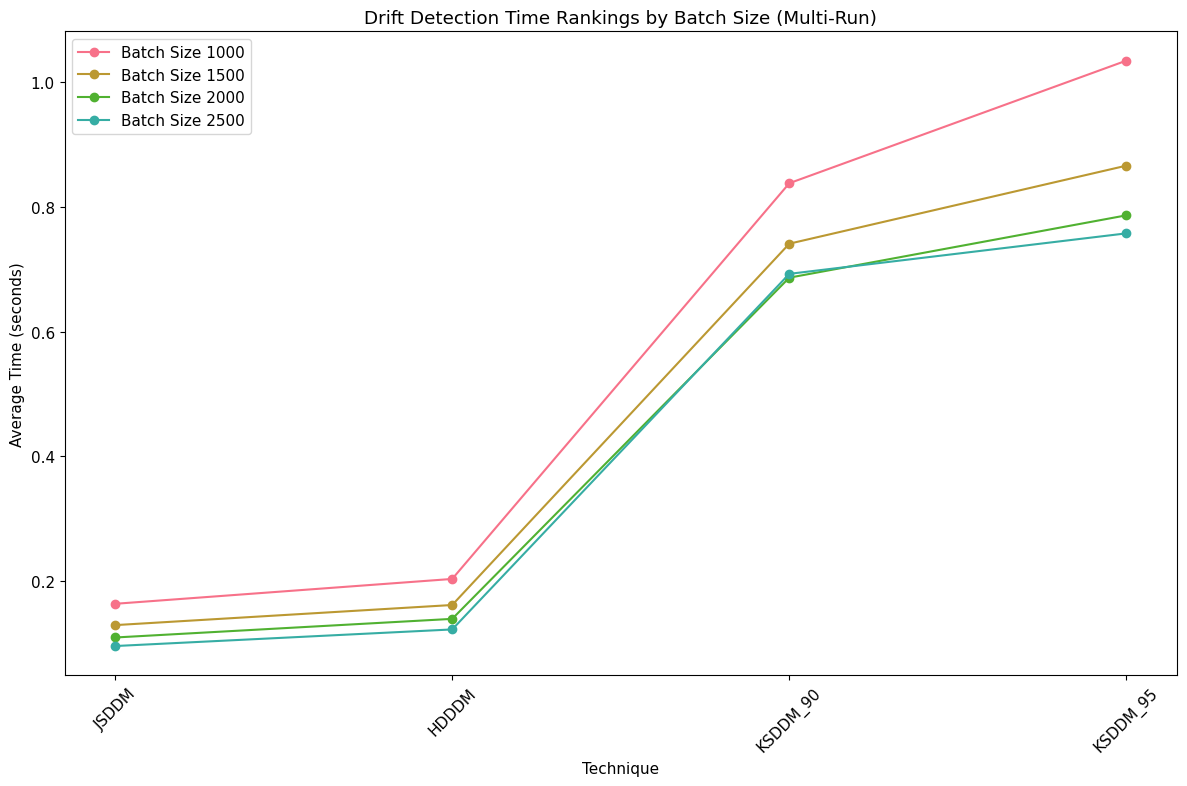

In [40]:
# Analyze Technique Rankings by Batch Size
batch_size_ranking = drift_detection_data[drift_detection_data['batch_size'] != 'ALL'].groupby(['batch_size', 'technique'])['duration_seconds'].mean().reset_index()
batch_size_ranking = batch_size_ranking.sort_values(['batch_size', 'duration_seconds'])

# Plot rankings for each batch size
unique_batch_sizes = batch_size_ranking['batch_size'].unique()
plt.figure(figsize=(12, 8))
for batch_size in unique_batch_sizes:
    subset = batch_size_ranking[batch_size_ranking['batch_size'] == batch_size]
    plt.plot(subset['technique'], subset['duration_seconds'], marker='o', label=f'Batch Size {batch_size}')

plt.title('Drift Detection Time Rankings by Batch Size (Multi-Run)')
plt.xlabel('Technique')
plt.ylabel('Average Time (seconds)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('./images/technique_rankings_by_batch_size.png')
plt.show()

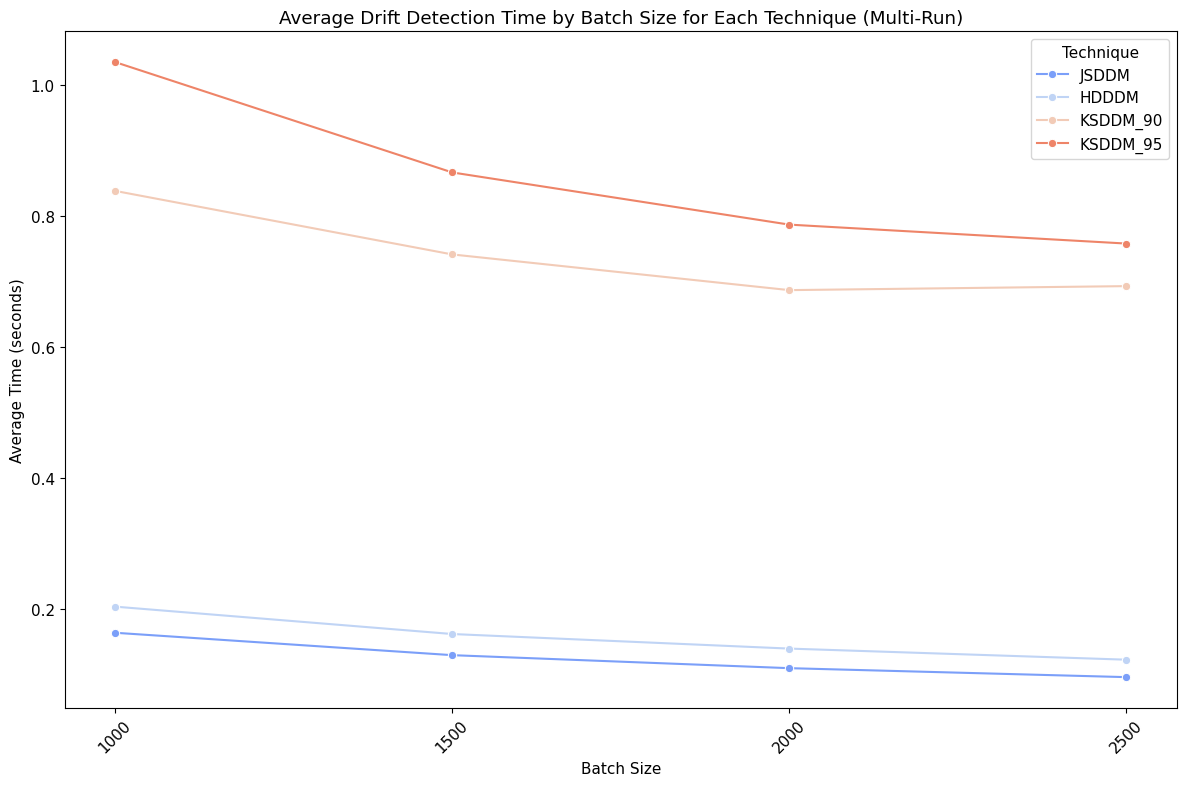

In [41]:
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=batch_size_ranking,
    x='batch_size',
    y='duration_seconds',
    hue='technique',
    marker='o',
    palette='coolwarm'
)
plt.title('Average Drift Detection Time by Batch Size for Each Technique (Multi-Run)')
plt.xlabel('Batch Size')
plt.ylabel('Average Time (seconds)')
plt.xticks(rotation=45)
plt.legend(title='Technique')
plt.tight_layout()
plt.savefig('./images/average_time_by_batch_size_per_technique.png')
plt.show()

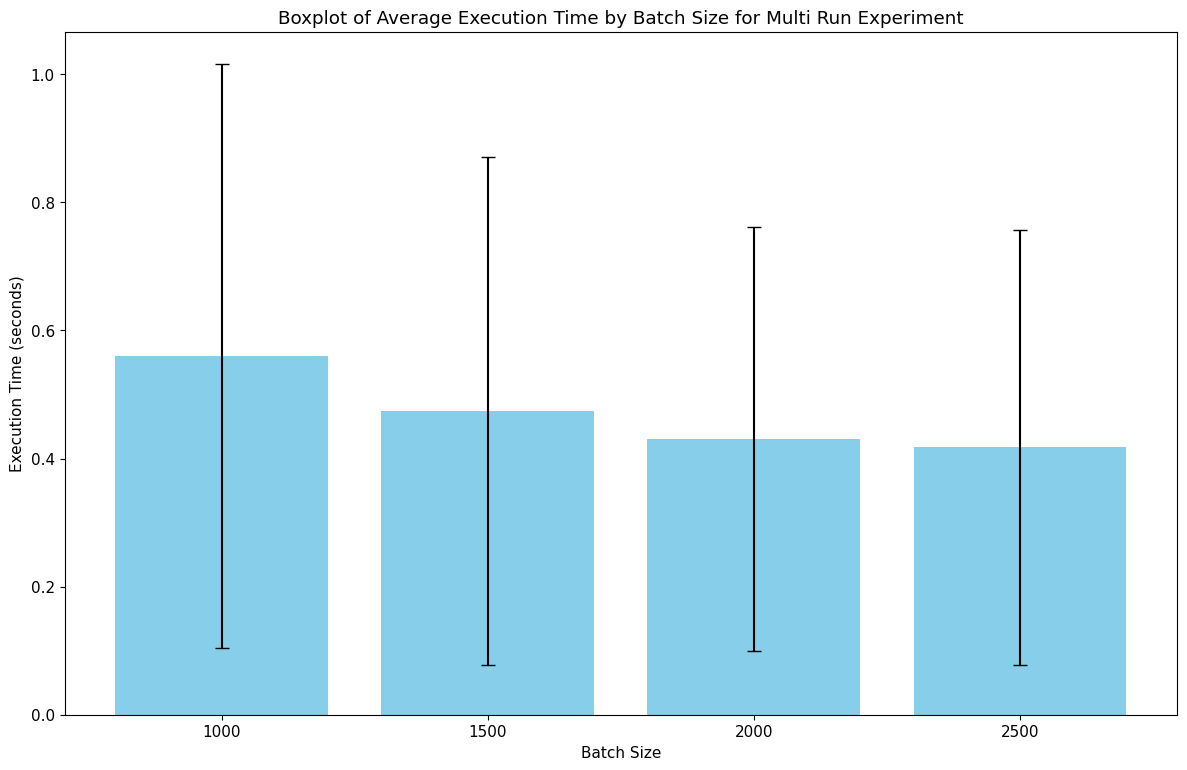

In [42]:
# Create a boxplot for average execution time by batch size
plt.figure(figsize=(12, 8))

# Calculate mean execution time per batch size
batch_stds = drift_detection_data[drift_detection_data['batch_size'] != 'ALL'].groupby('batch_size')['duration_seconds'].std()
batch_means = drift_detection_data[drift_detection_data['batch_size'] != 'ALL'].groupby('batch_size')['duration_seconds'].mean()
plt.bar(batch_means.index, batch_means.values, yerr=batch_stds.values, color='skyblue', capsize=5)
plt.title('Boxplot of Average Execution Time by Batch Size for Multi Run Experiment')
plt.suptitle('')  # Remove the automatic subtitle
plt.xlabel('Batch Size')
plt.ylabel('Execution Time (seconds)')
plt.tight_layout()
plt.show()

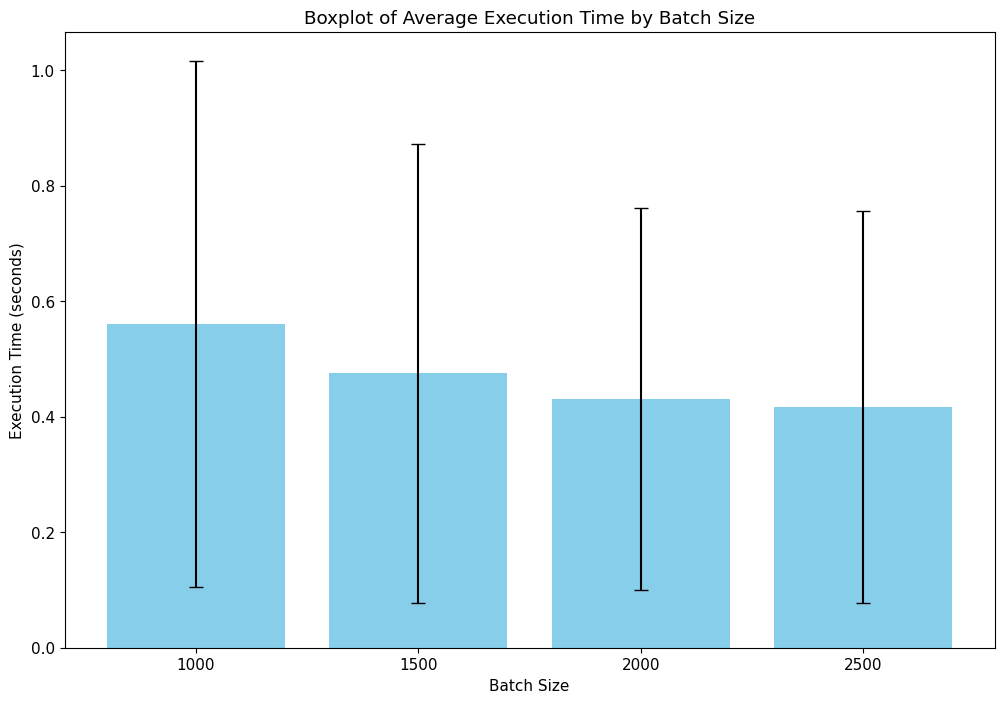

In [43]:
# Set lower error to be the min between std and mean (to not go below 0)
lower_errors = np.minimum(batch_stds, batch_means)
upper_errors = batch_stds

asymmetric_error = [lower_errors, upper_errors]

plt.figure(figsize=(12, 8))
plt.bar(batch_means.index, batch_means.values, yerr=asymmetric_error, color='skyblue', capsize=5)
plt.xlabel("Batch Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Boxplot of Average Execution Time by Batch Size")
plt.grid(False)
plt.show()

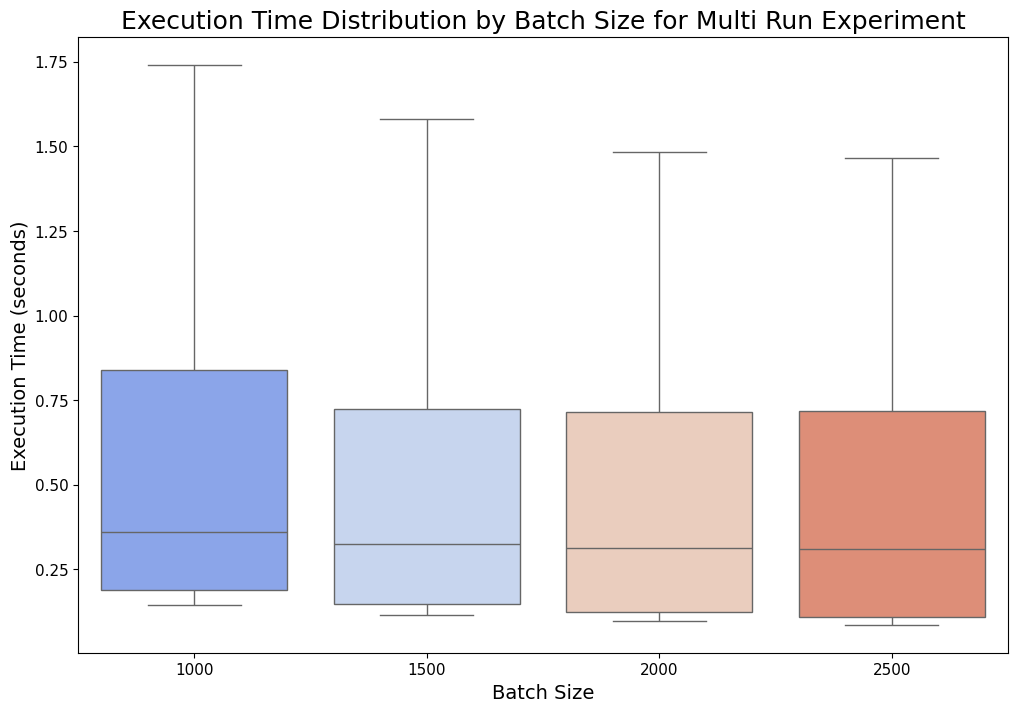

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc('axes', titlesize=18)  # Set default title size
plt.rc('axes', labelsize=14)  # Set default label size 

DEFAULT_FIGSIZE = (12, 8)

plt.figure(figsize=DEFAULT_FIGSIZE)

sns.boxplot(data=drift_detection_data[drift_detection_data['batch_size'] != 'ALL'],
            x='batch_size', y='duration_seconds', palette='coolwarm', showfliers=False)
plt.xlabel("Batch Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Distribution by Batch Size for Multi Run Experiment")
plt.grid(False)
plt.savefig('./images/execution_time_boxplot_multi_run.png')
plt.show()


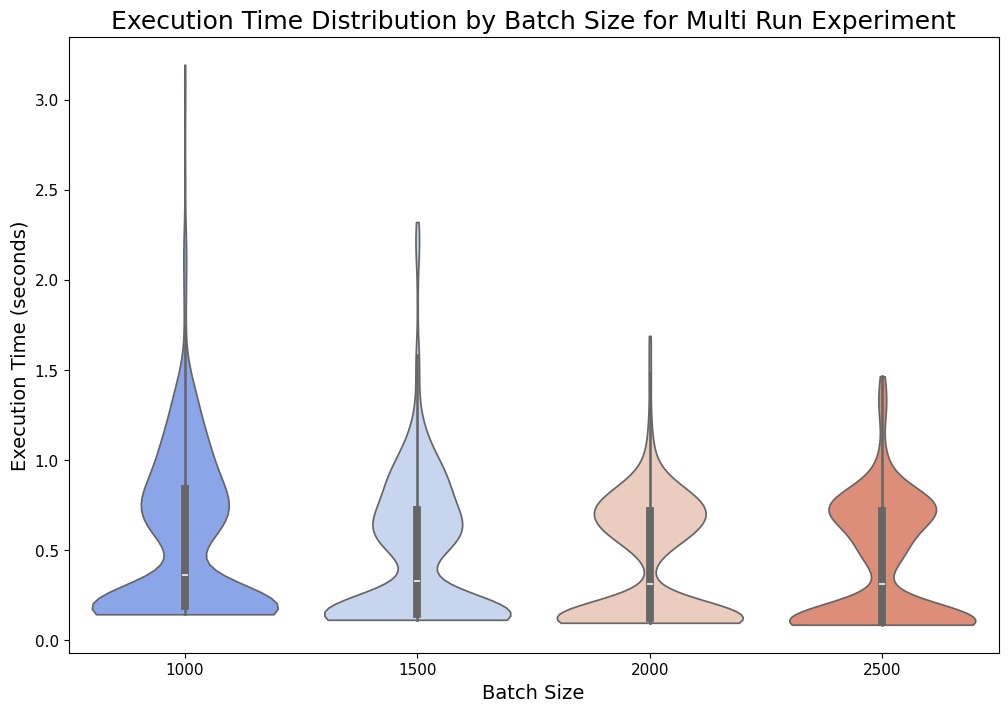

In [45]:
plt.figure(figsize=DEFAULT_FIGSIZE)
sns.violinplot(data=drift_detection_data[drift_detection_data['batch_size'] != 'ALL'],
               x='batch_size', y='duration_seconds', palette='coolwarm', cut=0)
plt.xlabel("Batch Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Distribution by Batch Size for Multi Run Experiment")
plt.grid(False)
plt.savefig('./images/execution_time_violinplot_multi_run.png')
plt.show()